# ============================================
# 1. IMPORT LIBRARIES
# ============================================

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Explainability
import shap

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


# ============================================
# 2. LOAD DATASET
# ============================================

In [ ]:
df = pd.read_csv("online_shoppers_intention.csv")

print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (12330, 18)
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10      

# ============================================
# 3. DATA PREPROCESSING
# ============================================

In [ ]:
# Convert target variable to binary
df['Revenue'] = df['Revenue'].astype(int)

# Encode categorical variables
label_encoder = LabelEncoder()
df['Month'] = label_encoder.fit_transform(df['Month'])

df = pd.get_dummies(df, columns=['VisitorType'], drop_first=True)

# Convert boolean to int
df['Weekend'] = df['Weekend'].astype(int)


In [ ]:
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue,VisitorType_Other,VisitorType_Returning_Visitor
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,2,1,1,1,1,0,0,False,True
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,2,2,2,1,2,0,0,False,True
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,2,4,1,9,3,0,0,False,True
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,2,3,2,2,4,0,0,False,True
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,2,3,3,1,4,1,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,1,4,6,1,1,1,0,False,True
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,7,3,2,1,8,1,0,False,True
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,7,3,2,1,13,1,0,False,True
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,7,2,2,3,11,0,0,False,True


## 3A. EXPLORATORY DATA ANALYSIS (EDA)


===== BASIC INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 19 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  Month                          12330 non-null  int64  
 11  OperatingSystems               12330 non-null  int64  
 12  Browser        

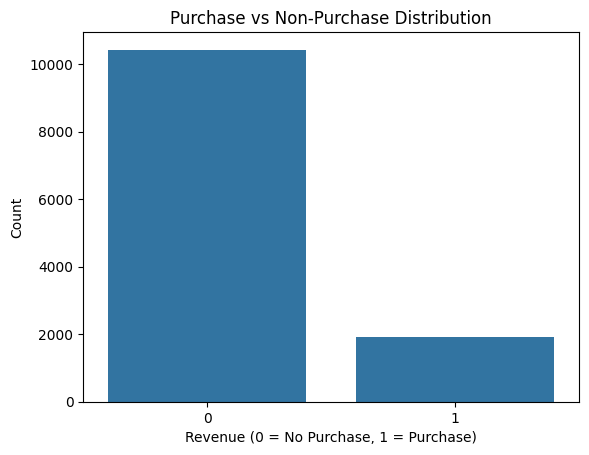

Class Distribution:
 Revenue
0    0.845255
1    0.154745
Name: proportion, dtype: float64


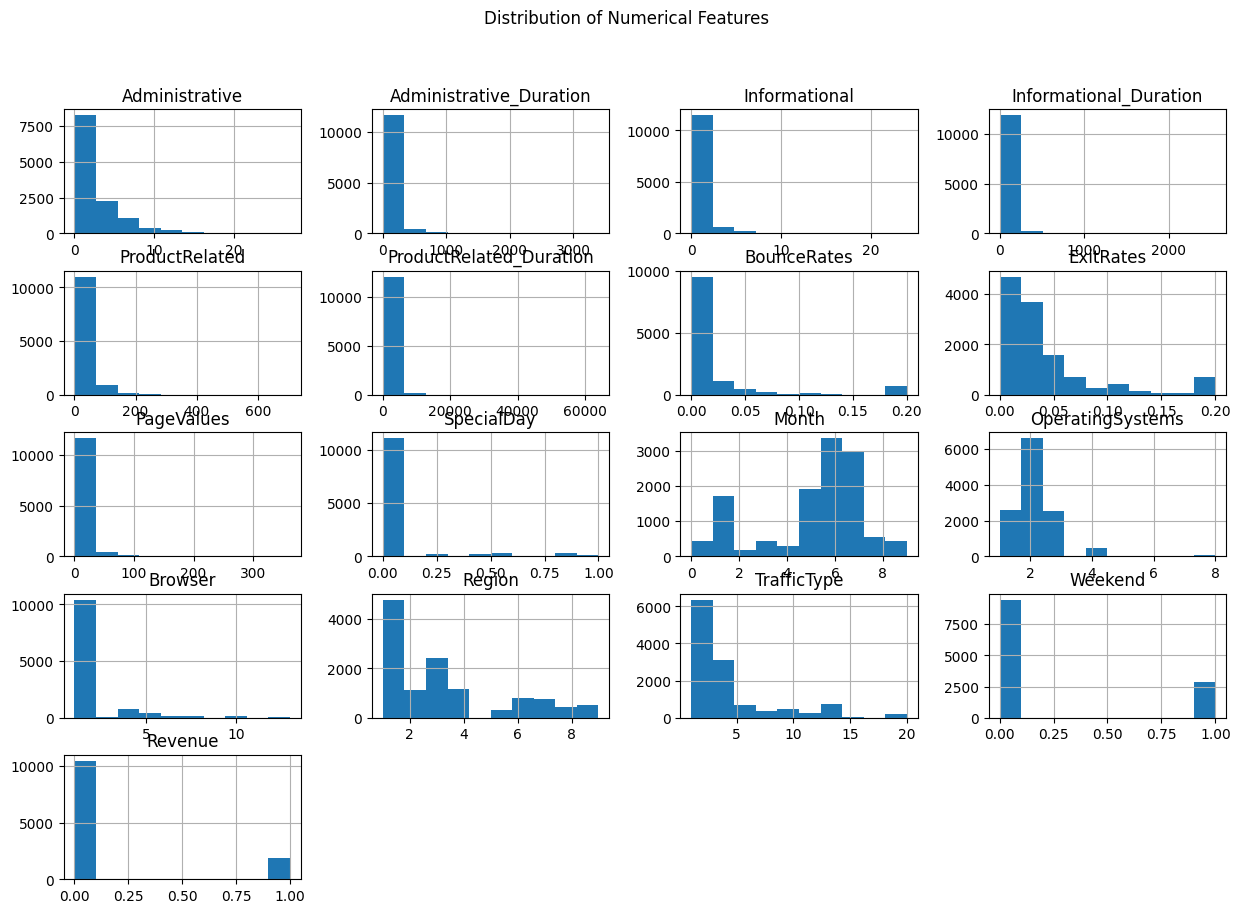

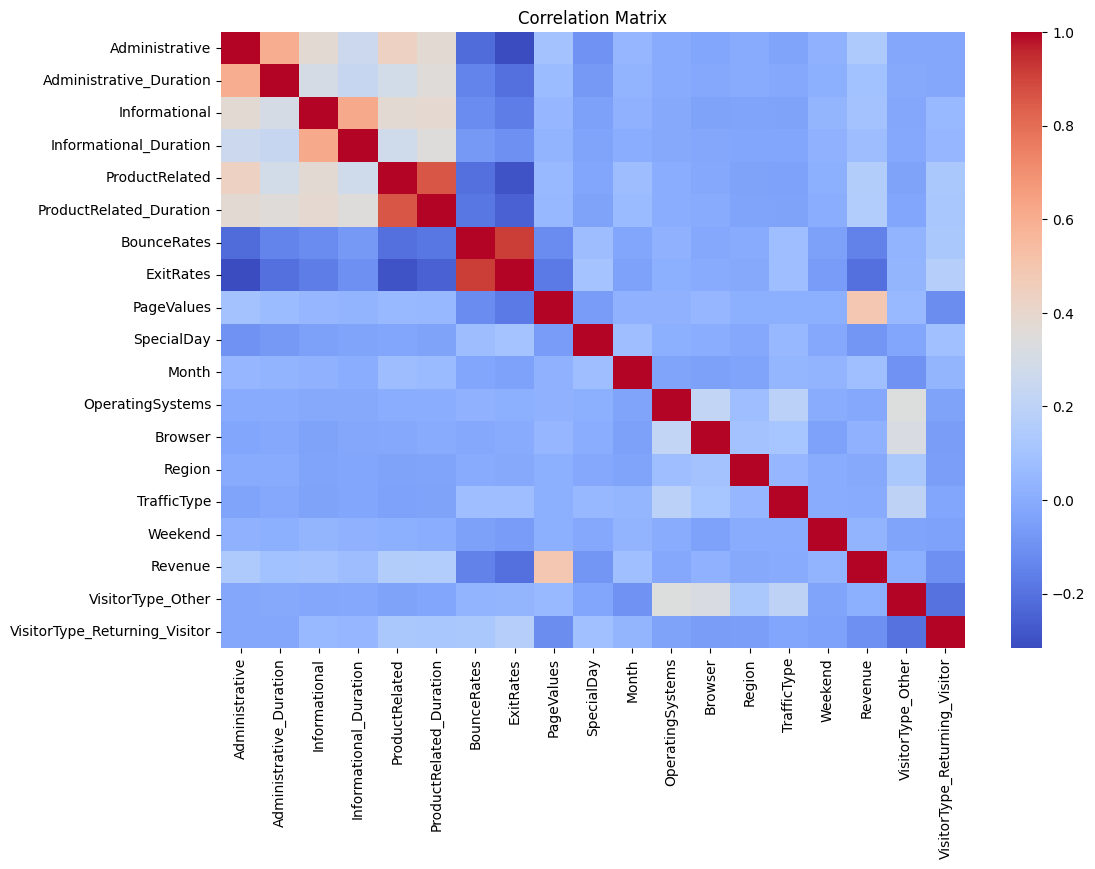

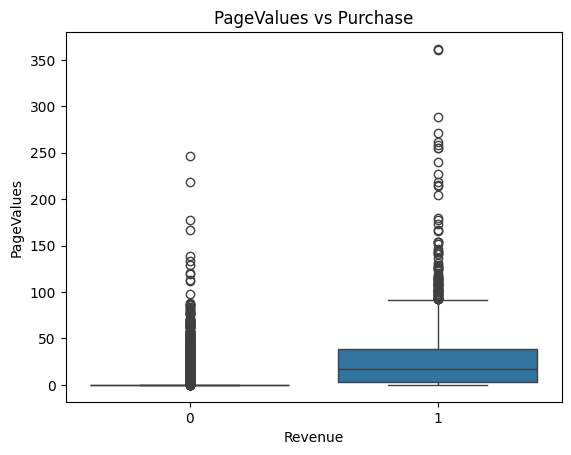

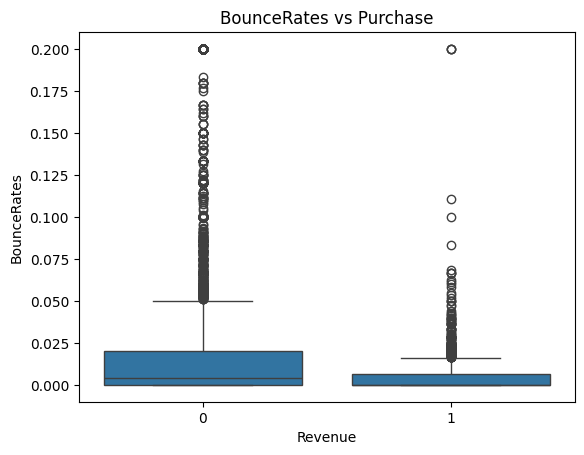

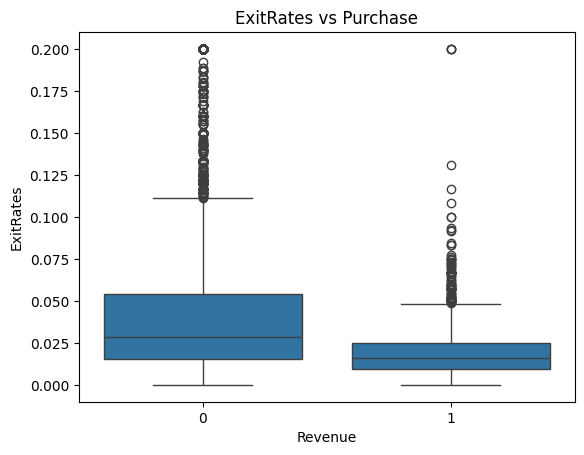

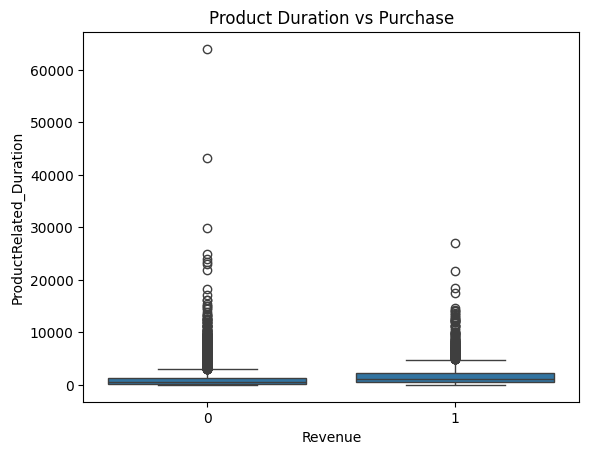

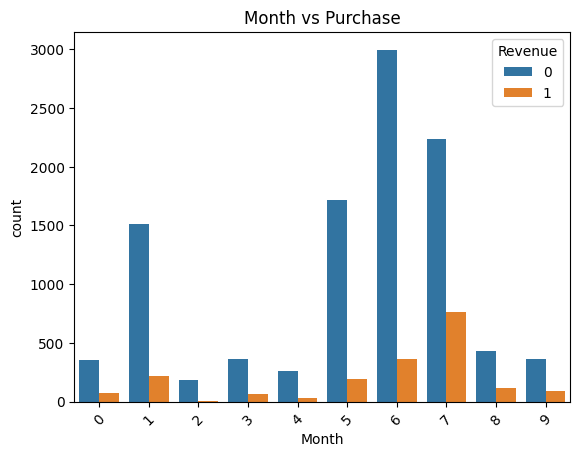

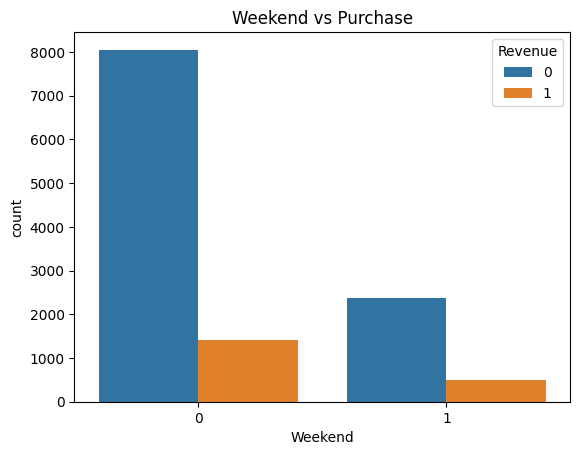

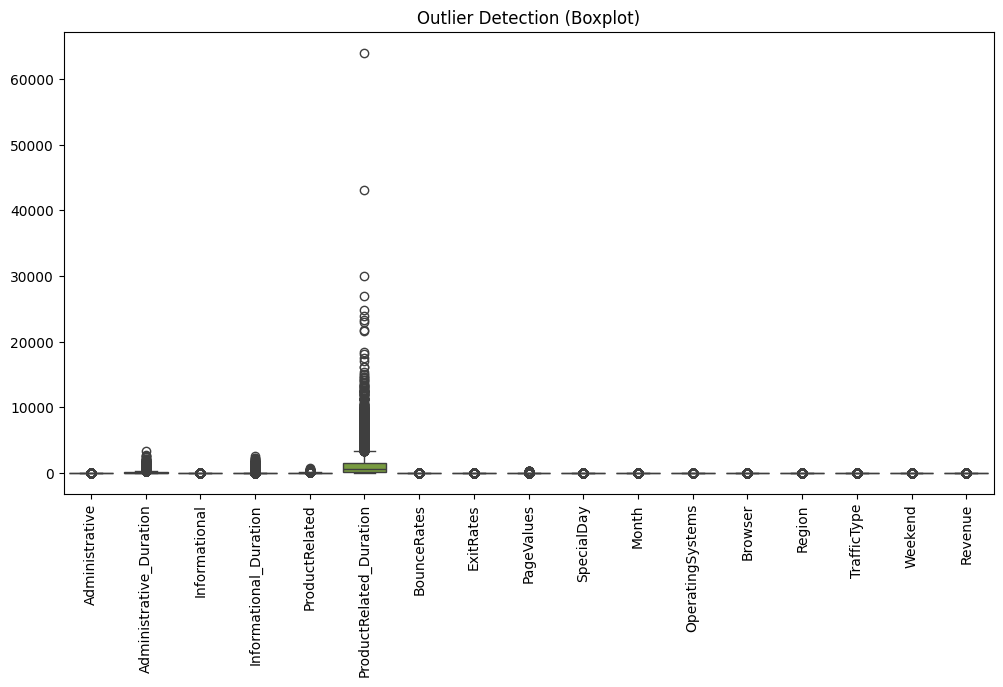

In [ ]:
# Basic Info
print("\n===== BASIC INFORMATION =====")
print(df.info())
print("\nDescriptive Statistics:\n", df.describe())

#  TARGET VARIABLE DISTRIBUTION
print("\n===== TARGET VARIABLE DISTRIBUTION =====")
sns.countplot(x='Revenue', data=df)
plt.title("Purchase vs Non-Purchase Distribution")
plt.xlabel("Revenue (0 = No Purchase, 1 = Purchase)")
plt.ylabel("Count")
plt.show()

# Check imbalance ratio
print("Class Distribution:\n", df['Revenue'].value_counts(normalize=True))

# NUMERICAL FEATURE DISTRIBUTIONS
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols].hist(figsize=(15, 10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

# CORRELATION MATRIX
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# KEY FEATURE VS TARGET ANALYSIS

# PageValues vs Revenue
sns.boxplot(x='Revenue', y='PageValues', data=df)
plt.title("PageValues vs Purchase")
plt.show()

# BounceRates vs Revenue
sns.boxplot(x='Revenue', y='BounceRates', data=df)
plt.title("BounceRates vs Purchase")
plt.show()

# ExitRates vs Revenue
sns.boxplot(x='Revenue', y='ExitRates', data=df)
plt.title("ExitRates vs Purchase")
plt.show()

# ProductRelated Duration vs Revenue
sns.boxplot(x='Revenue', y='ProductRelated_Duration', data=df)
plt.title("Product Duration vs Purchase")
plt.show()

#  CATEGORICAL FEATURE ANALYSIS

# Month vs Purchase
sns.countplot(x='Month', hue='Revenue', data=df)
plt.title("Month vs Purchase")
plt.xticks(rotation=45)
plt.show()

# Weekend Effect
sns.countplot(x='Weekend', hue='Revenue', data=df)
plt.title("Weekend vs Purchase")
plt.show()

#  OUTLIER DETECTION

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_cols])
plt.title("Outlier Detection (Boxplot)")
plt.xticks(rotation=90)
plt.show()

# ============================================
# 4. FEATURE & TARGET SPLIT
# ============================================

In [ ]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

# ============================================
# 5. TRAIN-TEST SPLIT
# ============================================

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# ============================================
# 6. FEATURE SCALING
# ============================================

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 7. HANDLE CLASS IMBALANCE (SMOTE)
# ============================================

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", np.bincount(y_train_resampled))


After SMOTE: [8338 8338]


# ============================================
# 8. MODEL DEFINITIONS
# ============================================

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(eval_metric='logloss', use_label_encoder=False)
}


# ============================================
# 9. MODEL TRAINING & EVALUATION
# ============================================


===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2084
           1       0.56      0.71      0.63       382

    accuracy                           0.87      2466
   macro avg       0.75      0.81      0.77      2466
weighted avg       0.89      0.87      0.87      2466

ROC-AUC: 0.8727891891348695


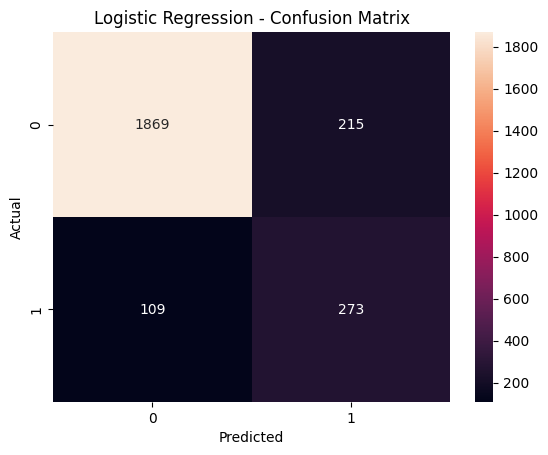


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2084
           1       0.62      0.68      0.65       382

    accuracy                           0.88      2466
   macro avg       0.78      0.80      0.79      2466
weighted avg       0.89      0.88      0.89      2466

ROC-AUC: 0.9199705308960818


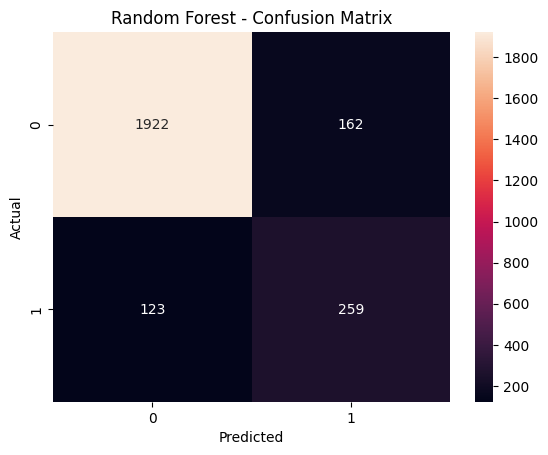


===== SVM =====
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      2084
           1       0.55      0.71      0.62       382

    accuracy                           0.86      2466
   macro avg       0.75      0.80      0.77      2466
weighted avg       0.88      0.86      0.87      2466

ROC-AUC: 0.8657522786425622


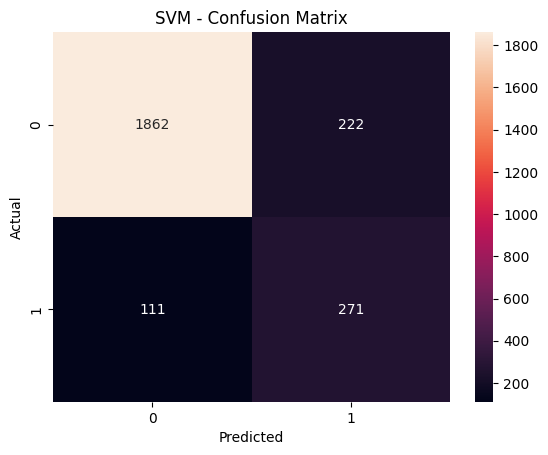


===== XGBoost =====
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      2084
           1       0.68      0.63      0.65       382

    accuracy                           0.90      2466
   macro avg       0.80      0.79      0.80      2466
weighted avg       0.89      0.90      0.89      2466

ROC-AUC: 0.9193443438413843


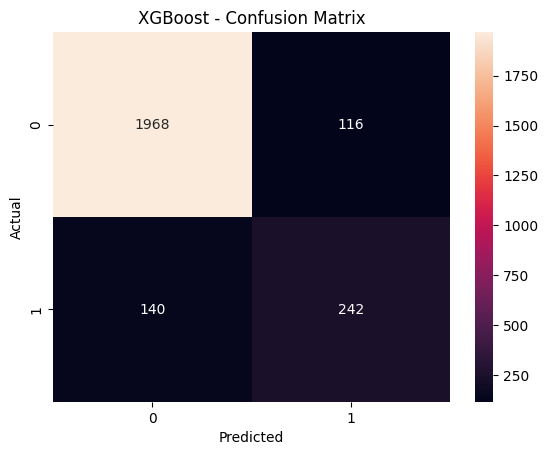

In [ ]:
results = {}

for name, model in models.items():
    print(f"\n===== {name} =====")

    # Train model
    model.fit(X_train_resampled, y_train_resampled)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    print(classification_report(y_test, y_pred))

    roc_auc = roc_auc_score(y_test, y_prob)
    print("ROC-AUC:", roc_auc)

    # Store results
    results[name] = roc_auc

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ============================================
# 10. MODEL COMPARISON
# ============================================

In [ ]:
print("\nModel Performance Comparison (ROC-AUC):")
for model, score in results.items():
    print(f"{model}: {score:.4f}")


Model Performance Comparison (ROC-AUC):
Logistic Regression: 0.8728
Random Forest: 0.9200
SVM: 0.8658
XGBoost: 0.9193


# ============================================
# 11. ROC CURVE PLOT
# ============================================

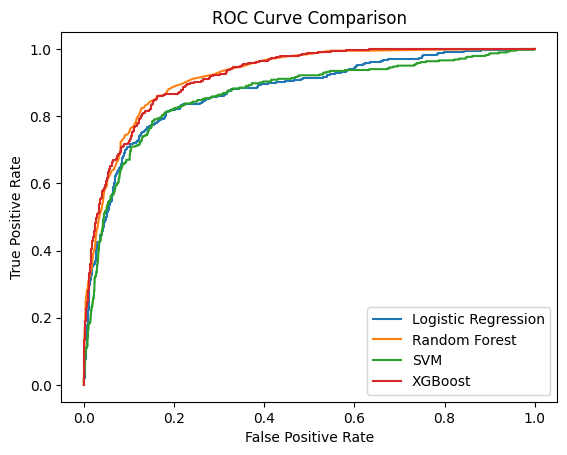

In [ ]:
plt.figure()

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ============================================
# 12. FEATURE IMPORTANCE (RANDOM FOREST)
# ============================================

                    Feature  Importance
8                PageValues    0.453282
7                 ExitRates    0.078789
0            Administrative    0.069892
5   ProductRelated_Duration    0.060397
10                    Month    0.059900
4            ProductRelated    0.051681
1   Administrative_Duration    0.039913
6               BounceRates    0.037892
14              TrafficType    0.036810
13                   Region    0.025871


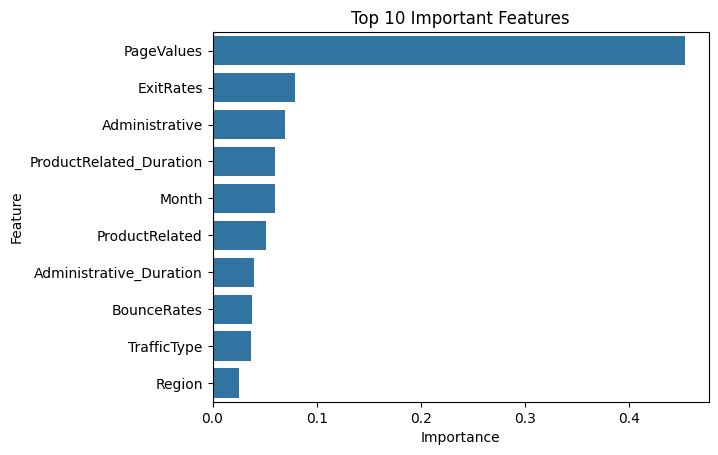

In [ ]:
rf_model = models["Random Forest"]
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

sns.barplot(data=feature_importance_df.head(10), x='Importance', y='Feature')
plt.title("Top 10 Important Features")
plt.show()


# ============================================
# 13. SHAP EXPLAINABILITY (XGBOOST)
# ============================================

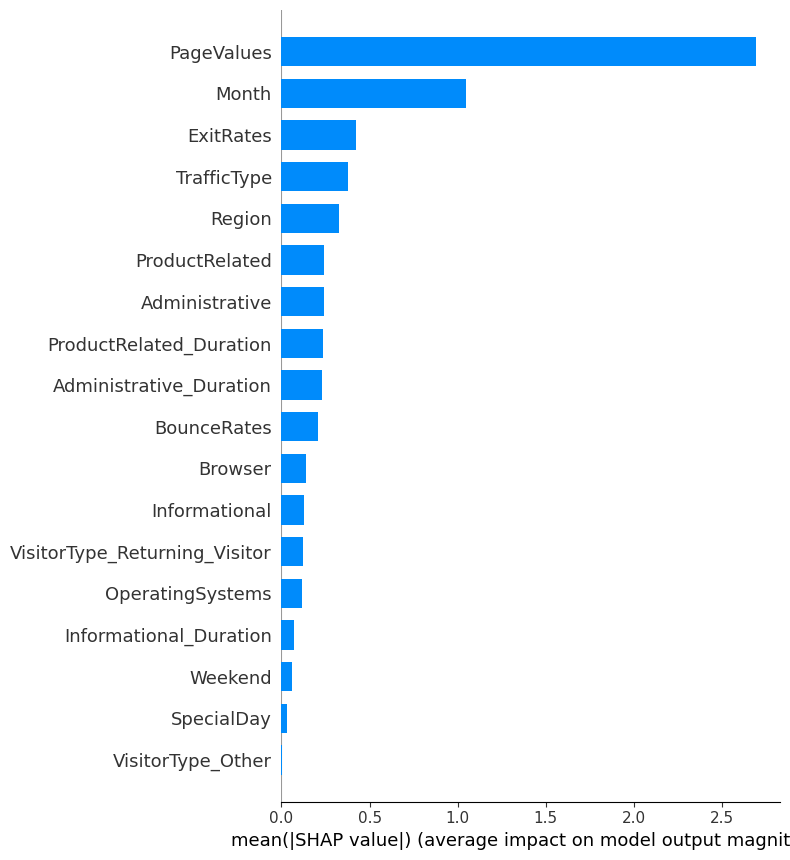

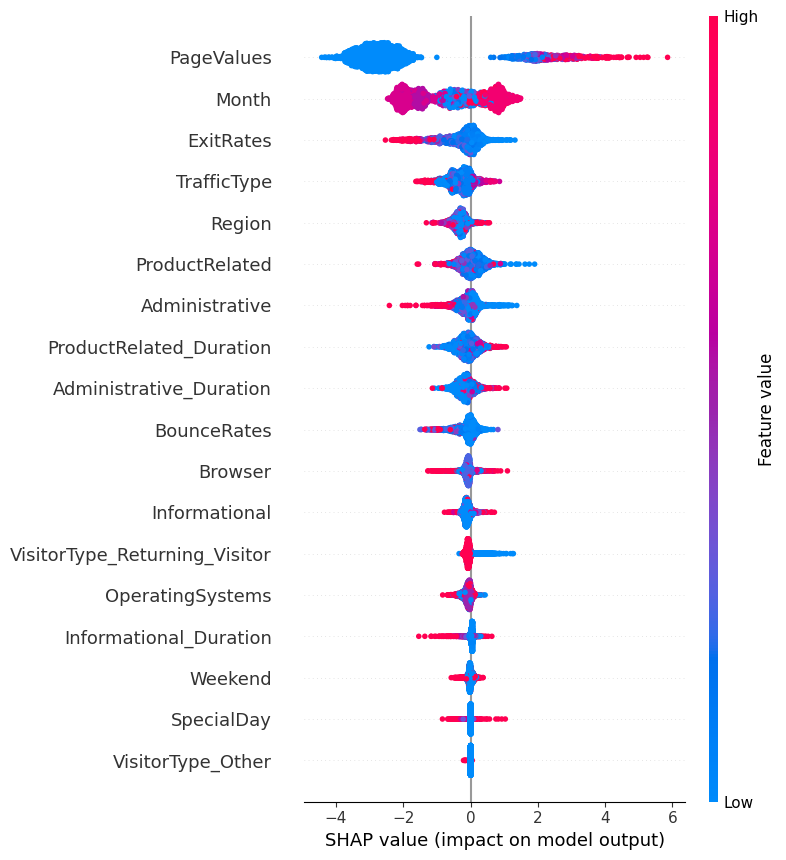

In [ ]:
explainer = shap.Explainer(models["XGBoost"])
shap_values = explainer(X_test_scaled)

# Summary Plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

# Detailed Plot
shap.summary_plot(shap_values, X_test)